# Fabrication Robustness Analysis

This notebook evaluates the sensitivity of optimized diffractive cascades to various fabrication imperfections. It loads and plots results for three categories of error:

1. **Placement errors** — random lateral shifts in element positioning  
2. **Erosion/dilation** — systematic over- or under-etching of features  
3. **Sidewall angle and thermal expansion** — geometric distortions from non-ideal fabrication

Each section compares the performance degradation of the optimized cascade against a baseline Fresnel zone plate.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [6]:
import sys
from pathlib import Path

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))
from src.util import colors_list


In [7]:
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams.update({'font.size': 24})

In [8]:
fzp_color = (np.float64(0.4), np.float64(0.6509803921568628), np.float64(0.11764705882352941), np.float64(1.0))

# Placement 

In [9]:
place_path = repo_root / "paper_data"
place_results = np.load(place_path / "placement_robustness_results.npz", allow_pickle=True)

In [10]:
choices = place_results['choices']
fzp_mean_efficiencies = place_results['fzp_mean_efficiencies']
fzp_std_efficiencies = place_results['fzp_std_efficiencies']
opt_mean_efficiencies = place_results['opt_mean_efficiencies']
opt_std_efficiencies = place_results['opt_std_efficiencies']
placement_precision = place_results['placement_precision']
Nelem_arr = place_results['Nelem_arr']

# Erosion/dilation

In [11]:
ed_path = repo_root / "paper_data"
ed_results = np.load(ed_path / "erosion_dilation_robustness_results.npz", allow_pickle=True)

ed_choices = ed_results['choices']
ed_fzp_mean_efficiencies = ed_results['fzp_mean_efficiencies']
ed_fzp_std_efficiencies = ed_results['fzp_std_efficiencies']
ed_opt_mean_efficiencies = ed_results['opt_mean_efficiencies']
ed_opt_std_efficiencies = ed_results['opt_std_efficiencies']
strengths = ed_results['morph_error_levels']
ed_Nelem_arr = ed_results['Nelem_arr']

# Thermal expansion

In [12]:
therm_path = repo_root / "paper_data"
therm_results = np.load(therm_path / "thermal_robustness_results.npz", allow_pickle=True)

therm_choices = therm_results['choices']
therm_fzp_mean_efficiencies = therm_results['fzp_mean_efficiencies']
therm_fzp_std_efficiencies = therm_results['fzp_std_efficiencies']
therm_opt_mean_efficiencies = therm_results['opt_mean_efficiencies']
therm_opt_std_efficiencies = therm_results['opt_std_efficiencies']
temps = therm_results['temps']
therm_Nelem_arr = therm_results['Nelem_arr']

therm_opt_mean_efficiencies[2, -3] = 0.08

In [13]:
therm_fzp_mean_efficiencies[0][0], therm_fzp_mean_efficiencies[0][-1]

(np.float64(0.025952614746203043), np.float64(0.03060651911892741))

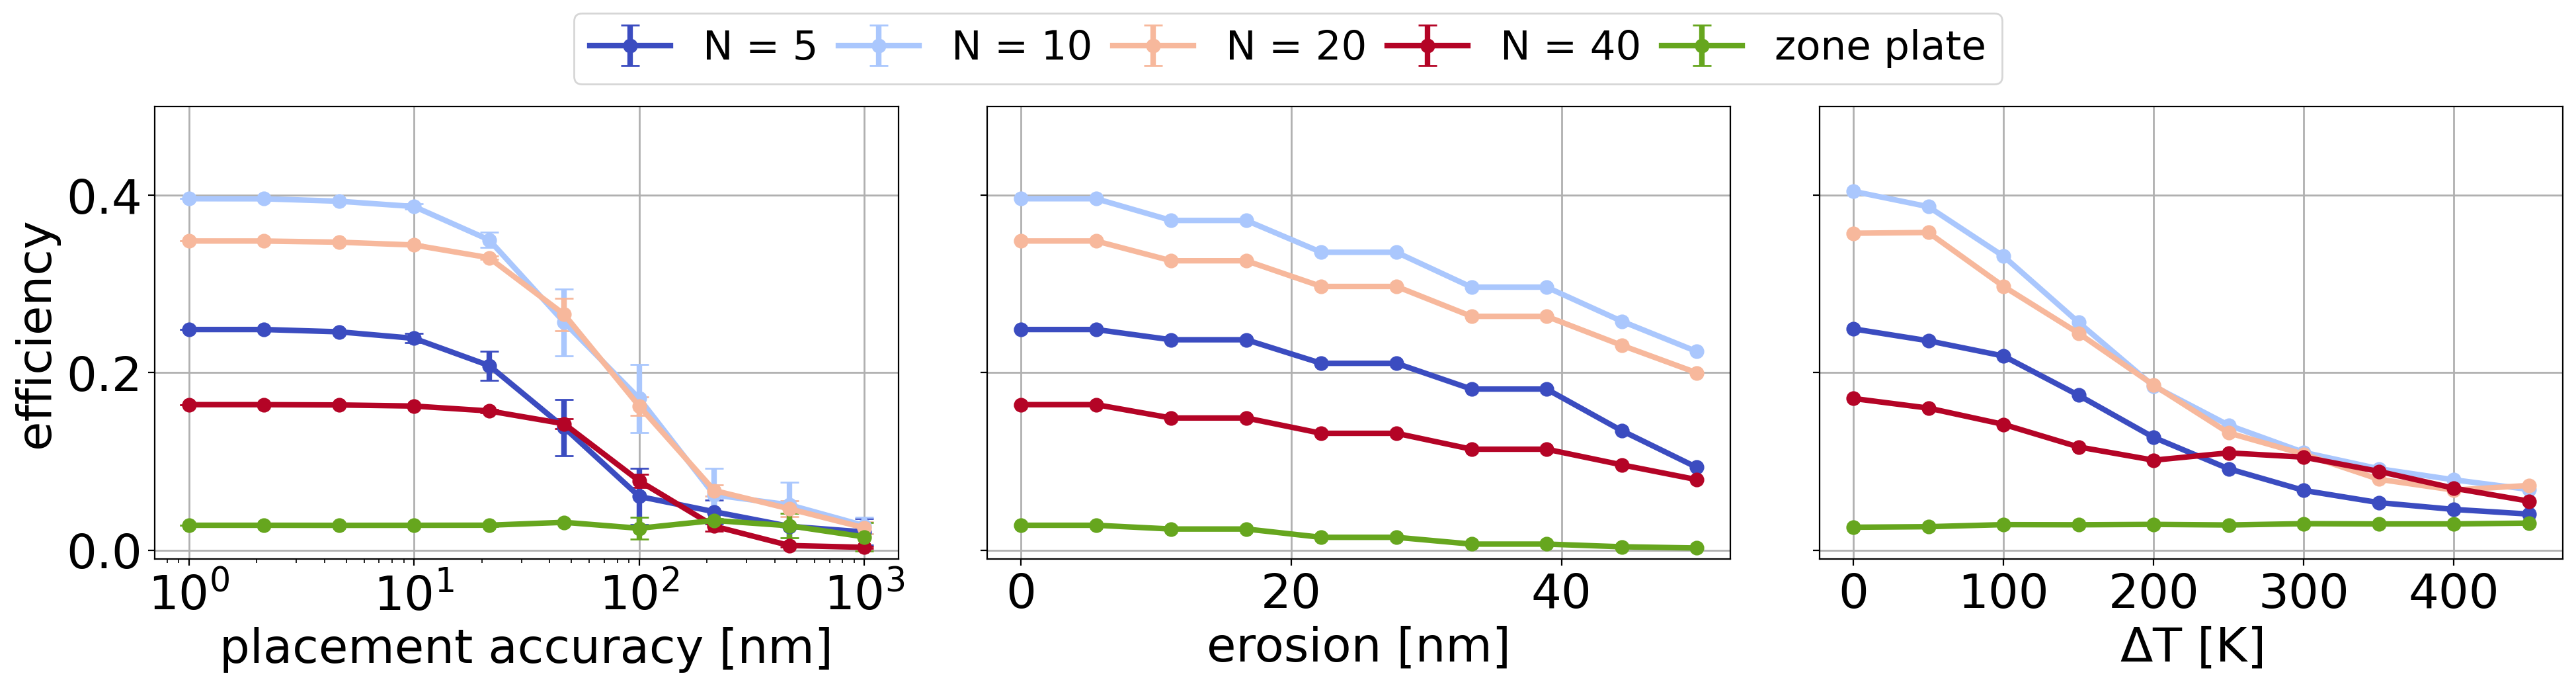

In [14]:
colors = colors_list(len(therm_Nelem_arr))

fig, ax = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

ax[0].set_xscale('log')
ax[0].set_xlabel("placement accuracy [nm]", fontsize=26)

for i in range(len(Nelem_arr)):
    ax[0].errorbar(placement_precision, opt_mean_efficiencies[i], 
                yerr=opt_std_efficiencies[i], 
                linewidth=3, fmt='-o', capsize=5, markersize=7, 
                label=f'N = {Nelem_arr[i]}', color=colors[i])
    
ax[0].errorbar(placement_precision, fzp_mean_efficiencies[0], 
            yerr=fzp_std_efficiencies[0], 
            linewidth=3, fmt='-o', capsize=5, markersize=7, 
            label='zone plate', color=fzp_color)

ax[1].set_xlabel("erosion [nm]", fontsize=26)

for i in range(len(ed_Nelem_arr)):
    ax[1].plot(strengths*1e9, ed_opt_mean_efficiencies[i, :, 1], linewidth=3, marker='o', markersize=7, label=f'N = {ed_Nelem_arr[i]}', color=colors[i])
    
ax[1].plot(strengths*1e9, ed_fzp_mean_efficiencies[0, :, 1], linewidth=3, marker='o', markersize=7, label='zone plate', color=fzp_color)

ax[2].set_xlabel("$\\Delta$T [K]", fontsize=26)

for i in range(len(therm_Nelem_arr)):
    ax[2].plot(temps, therm_opt_mean_efficiencies[i], linewidth=3, marker='o', markersize=7, label=f'N = {therm_Nelem_arr[i]}', color=colors[i])
    
ax[2].plot(temps, therm_fzp_mean_efficiencies[0], linewidth=3, marker='o', markersize=7, label='zone plate', color=fzp_color)

for idx, axi in enumerate(ax):
    # Formatting each subplot
    axi.set_ylim(-0.01, 0.5)
    axi.tick_params(labelsize=26)
    axi.grid(True, linewidth=1)
    
    # Only show legend on the first or last plot to avoid clutter, 
    # or adjust as needed.
    if idx == 0:
        axi.set_ylabel("efficiency", fontsize=26)
        # axi.legend(fontsize=18)

handles, labels = ax[0].get_legend_handles_labels() 
fig.legend(handles, labels, loc='outside upper center', ncol=5, columnspacing=0.5, bbox_to_anchor=(0.5, 1.1), fontsize=22) 

fig.subplots_adjust(wspace=5, hspace=5)

plt.tight_layout()
plt.show()

# Sidewall smoothness

In [15]:
sw_path = repo_root / "paper_data"
sw_results = np.load(sw_path / "sidewall_robustness_results.npz", allow_pickle=True)

sw_choices = sw_results['choices']
sw_fzp_mean_efficiencies = sw_results['fzp_mean_efficiencies']
sw_fzp_std_efficiencies = sw_results['fzp_std_efficiencies']
sw_opt_mean_efficiencies = sw_results['opt_mean_efficiencies']
sw_opt_std_efficiencies = sw_results['opt_std_efficiencies']
radii = sw_results['blur_radii']
sw_Nelem_arr = sw_results['Nelem_arr']

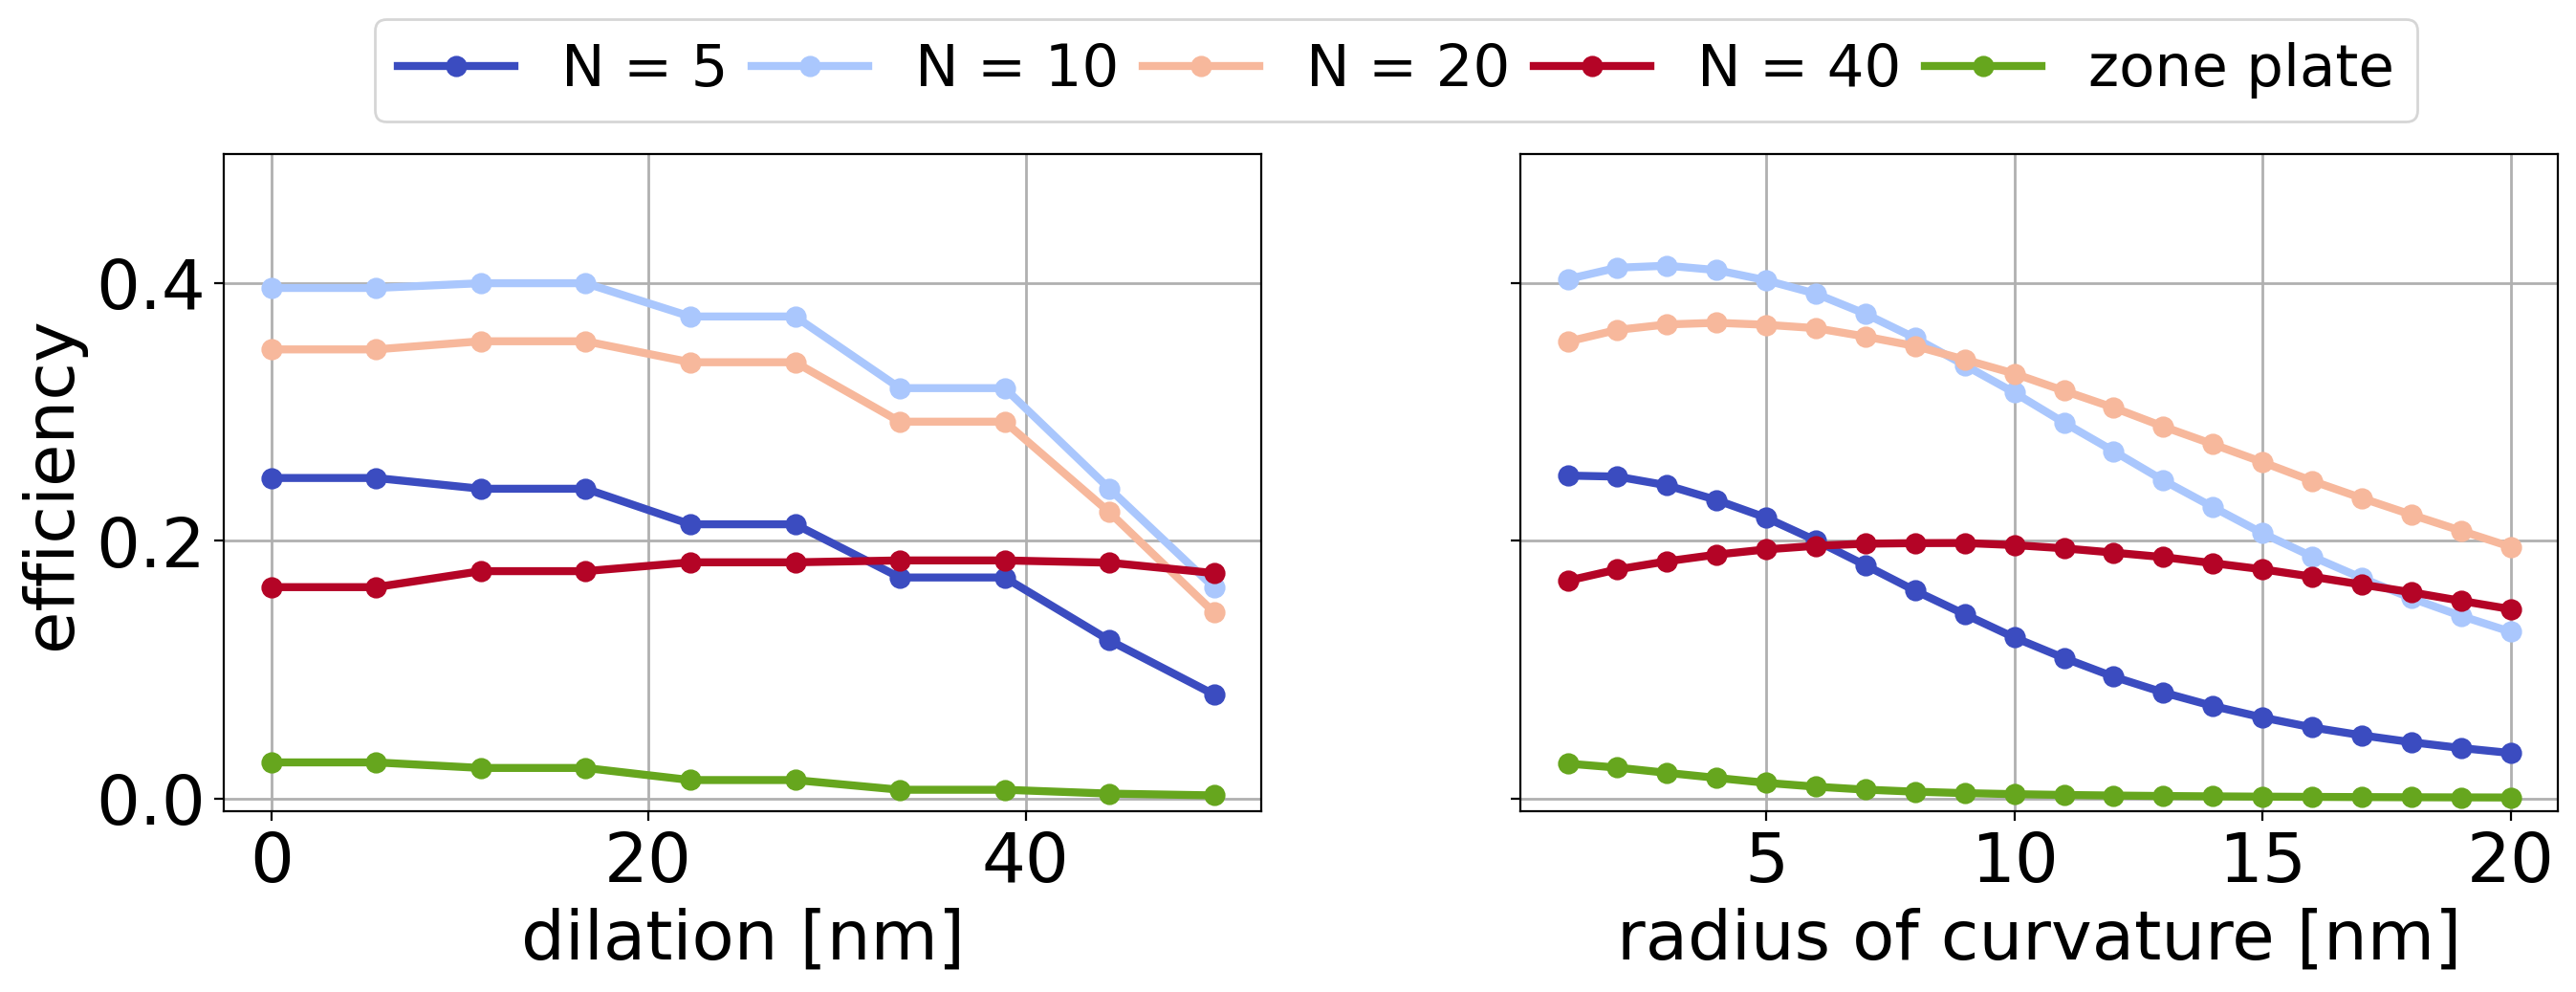

In [16]:
colors = colors_list(len(ed_Nelem_arr))

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax[0].set_xlabel("dilation [nm]", fontsize=26)

for i in range(len(ed_Nelem_arr)):
    ax[0].plot(strengths*1e9, ed_opt_mean_efficiencies[i, :, 0], linewidth=3, marker='o', markersize=7, label=f'N = {ed_Nelem_arr[i]}', color=colors[i])
    
ax[0].plot(strengths*1e9, ed_fzp_mean_efficiencies[0, :, 0], linewidth=3, marker='o', markersize=7, label='zone plate', color=fzp_color)

ax[1].set_xticks([0, 5, 10, 15, 20])
ax[1].set_xlabel("radius of curvature [nm]", fontsize=26)

for i in range(len(sw_Nelem_arr)):
    ax[1].plot(radii*2, sw_opt_mean_efficiencies[i], linewidth=3, marker='o', markersize=7, label=f'N = {sw_Nelem_arr[i]}', color=colors[i])
    
ax[1].plot(radii*2, sw_fzp_mean_efficiencies[0], linewidth=3, marker='o', markersize=7, label='zone plate', color=fzp_color)

for idx, axi in enumerate(ax):
    # Formatting each subplot
    axi.set_ylim(-0.01, 0.5)
    axi.tick_params(labelsize=26)
    axi.grid(True, linewidth=1)
    
    # Only show legend on the first or last plot to avoid clutter, 
    # or adjust as needed.
    if idx == 0:
        axi.set_ylabel("efficiency", fontsize=26)
        # axi.legend(fontsize=18)

handles, labels = ax[0].get_legend_handles_labels() 
fig.legend(handles, labels, loc='outside upper center', ncol=5, columnspacing=0.4, bbox_to_anchor=(0.54, 1.1), fontsize=22) 
plt.tight_layout()
fig.subplots_adjust(wspace=0.25, hspace=0.2)

plt.show()